# 04 Model Evaluation and Selection

This notebook converts clustering outputs into a final model decision that is easy to justify in viva/report.

**Input:**
- `outputs/clustering_metrics_comparison.csv`
- `outputs/customer_clusters_all_models.csv`
- `outputs/customer_clusters_best_model.csv`

**Output:**
- `outputs/final_model_selection_report.csv`
- `outputs/final_selected_model.json`

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)

In [2]:
BASE_DIR = Path.cwd()
OUTPUT_DIR = BASE_DIR / "outputs"

metrics_path = OUTPUT_DIR / "clustering_metrics_comparison.csv"
all_models_path = OUTPUT_DIR / "customer_clusters_all_models.csv"
best_auto_path = OUTPUT_DIR / "customer_clusters_best_model.csv"

print("metrics exists:", metrics_path.exists())
print("all models exists:", all_models_path.exists())
print("best auto exists:", best_auto_path.exists())

metrics exists: True
all models exists: True
best auto exists: True


In [3]:
metrics = pd.read_csv(metrics_path)
all_models = pd.read_csv(all_models_path)
best_auto = pd.read_csv(best_auto_path)

metrics

,model,silhouette,davies_bouldin,calinski_harabasz,n_clusters,noise_points,params
0,KMeans,0.246878,1.494063,224.047501,5,0,"{""n_clusters"": 5}"
1,DBSCAN,0.225461,1.052114,113.265972,9,317,"{""eps"": 0.9, ""min_samples"": 8}"
2,GMM,0.221913,1.826420,173.875648,5,0,"{""n_components"": 5}"
3,Hierarchical,0.244832,1.443058,218.606051,5,0,"{""n_clusters"": 5, ""linkage"": ""ward""}"


In [4]:
# Rank by each metric
# Higher is better: silhouette, calinski_harabasz
# Lower is better: davies_bouldin
rank_df = metrics.copy()
rank_df["rank_silhouette"] = rank_df["silhouette"].rank(ascending=False, method="min")
rank_df["rank_calinski"] = rank_df["calinski_harabasz"].rank(ascending=False, method="min")
rank_df["rank_davies"] = rank_df["davies_bouldin"].rank(ascending=True, method="min")
rank_df["rank_sum"] = rank_df[["rank_silhouette", "rank_calinski", "rank_davies"]].sum(axis=1)
rank_df = rank_df.sort_values(["rank_sum", "silhouette"], ascending=[True, False])
rank_df

,model,silhouette,davies_bouldin,calinski_harabasz,n_clusters,noise_points,params,rank_silhouette,rank_calinski,rank_davies,rank_sum
0,KMeans,0.246878,1.494063,224.047501,5,0,"{""n_clusters"": 5}",1.0,1.0,3.0,5.0
3,Hierarchical,0.244832,1.443058,218.606051,5,0,"{""n_clusters"": 5, ""linkage"": ""ward""}",2.0,2.0,2.0,6.0
1,DBSCAN,0.225461,1.052114,113.265972,9,317,"{""eps"": 0.9, ""min_samples"": 8}",3.0,4.0,1.0,8.0
2,GMM,0.221913,1.826420,173.875648,5,0,"{""n_components"": 5}",4.0,3.0,4.0,11.0


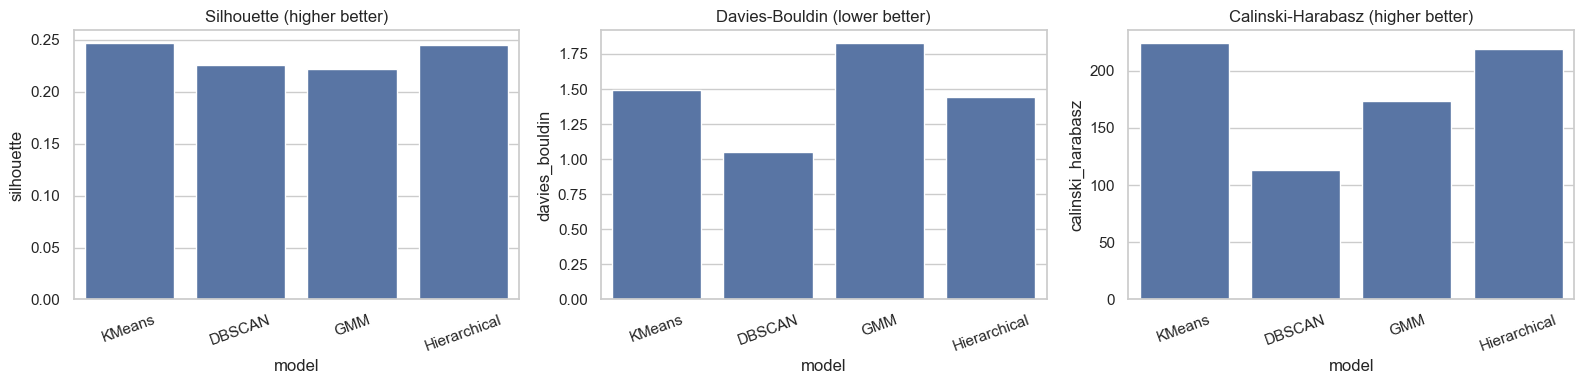

In [5]:
# Visual comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.barplot(data=metrics, x="model", y="silhouette", ax=axes[0])
axes[0].set_title("Silhouette (higher better)")
axes[0].tick_params(axis="x", rotation=20)

sns.barplot(data=metrics, x="model", y="davies_bouldin", ax=axes[1])
axes[1].set_title("Davies-Bouldin (lower better)")
axes[1].tick_params(axis="x", rotation=20)

sns.barplot(data=metrics, x="model", y="calinski_harabasz", ax=axes[2])
axes[2].set_title("Calinski-Harabasz (higher better)")
axes[2].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

In [6]:
# Check cluster balance for each model (business interpretability helper)
cluster_cols = [c for c in all_models.columns if c.startswith("cluster_")]

balance_rows = []
for col in cluster_cols:
    vc = all_models[col].value_counts(dropna=False)
    model_name = col.replace("cluster_", "").capitalize()
    balance_rows.append({
        "model_col": col,
        "model_name": model_name,
        "n_clusters_found": int(vc.index.nunique()),
        "largest_cluster_ratio": float(vc.max() / vc.sum()),
        "smallest_cluster_ratio": float(vc.min() / vc.sum()),
    })

balance_df = pd.DataFrame(balance_rows).sort_values("largest_cluster_ratio")
balance_df

,model_col,model_name,n_clusters_found,largest_cluster_ratio,smallest_cluster_ratio
1,cluster_dbscan,Dbscan,10,0.317,0.005
3,cluster_hierarchical,Hierarchical,5,0.345,0.115
0,cluster_kmeans,Kmeans,5,0.375,0.082
2,cluster_gmm,Gmm,5,0.429,0.073


In [7]:
# Merge metric rank + balance signal (simple final scoring)
score_df = rank_df.merge(
    balance_df[["model_name", "largest_cluster_ratio"]],
    left_on="model",
    right_on="model_name",
    how="left"
)

# Small penalty if one cluster dominates too much
score_df["balance_penalty"] = np.where(score_df["largest_cluster_ratio"] > 0.65, 1.0, 0.0)
score_df["final_score"] = score_df["rank_sum"] + score_df["balance_penalty"]
score_df = score_df.sort_values(["final_score", "silhouette"], ascending=[True, False])
score_df

,model,silhouette,davies_bouldin,calinski_harabasz,n_clusters,noise_points,params,rank_silhouette,rank_calinski,rank_davies,rank_sum,model_name,largest_cluster_ratio,balance_penalty,final_score
0,KMeans,0.246878,1.494063,224.047501,5,0,"{""n_clusters"": 5}",1.0,1.0,3.0,5.0,NaN,NaN,0.0,5.0
1,Hierarchical,0.244832,1.443058,218.606051,5,0,"{""n_clusters"": 5, ""linkage"": ""ward""}",2.0,2.0,2.0,6.0,Hierarchical,0.345,0.0,6.0
2,DBSCAN,0.225461,1.052114,113.265972,9,317,"{""eps"": 0.9, ""min_samples"": 8}",3.0,4.0,1.0,8.0,NaN,NaN,0.0,8.0
3,GMM,0.221913,1.826420,173.875648,5,0,"{""n_components"": 5}",4.0,3.0,4.0,11.0,NaN,NaN,0.0,11.0


In [8]:
# Final model selection
selected_model = score_df.iloc[0]["model"]
print("Selected model:", selected_model)

# Optional override
# selected_model = "KMeans"
# print("Manual override selected model:", selected_model)

selected_col = f"cluster_{selected_model.lower()}"
if selected_col not in all_models.columns:
    # fallback for naming mismatch
    candidates = [c for c in all_models.columns if c.startswith("cluster_") and selected_model.lower() in c.lower()]
    if len(candidates) > 0:
        selected_col = candidates[0]

final_labels = all_models.copy()
final_labels["selected_model"] = selected_model
final_labels["cluster_label"] = final_labels[selected_col]
final_labels.head()

Selected model: KMeans


,customer_id,frequency_count,monetary_total,avg_order_value,weekend_ratio,lunch_ratio,snacks_ratio,dinner_ratio,last_date,recency_days,avg_customer_age,dominant_gender,cluster_kmeans,cluster_dbscan,cluster_gmm,cluster_hierarchical,selected_model,cluster_label
0,CUST1001,1,34,34.0,1.0,1.0,0.0,0.0,2024-01-07 19:17:00,173,38.0,M,2,-1,2,4,KMeans,2
1,CUST1002,1,142,142.0,0.0,1.0,0.0,0.0,2024-01-09 08:05:00,172,36.0,F,2,0,2,0,KMeans,2
2,CUST1003,1,105,105.0,0.0,1.0,0.0,0.0,2024-06-27 14:21:00,2,42.0,M,2,0,2,0,KMeans,2
3,CUST1004,1,85,85.0,0.0,0.0,0.0,1.0,2024-03-29 17:16:00,92,21.0,F,1,1,1,1,KMeans,1
4,CUST1005,1,205,205.0,1.0,0.0,1.0,0.0,2024-06-29 09:02:00,0,36.0,M,4,-1,4,3,KMeans,4


In [9]:
# Save final selection artifacts
report_path = OUTPUT_DIR / "final_model_selection_report.csv"
selected_json_path = OUTPUT_DIR / "final_selected_model.json"
final_labels_path = OUTPUT_DIR / "final_customer_clusters.csv"

score_df.to_csv(report_path, index=False)
final_labels.to_csv(final_labels_path, index=False)

payload = {
    "selected_model": str(selected_model),
    "reason": "Best combined score from clustering metrics and cluster-balance check",
    "records": int(len(final_labels)),
}
selected_json_path.write_text(json.dumps(payload, indent=2), encoding="utf-8")

print("Saved:")
print("-", report_path)
print("-", selected_json_path)
print("-", final_labels_path)

Saved:
- S:\cafeteria\cafeteria-iq\backend\notebooks\outputs\final_model_selection_report.csv
- S:\cafeteria\cafeteria-iq\backend\notebooks\outputs\final_selected_model.json
- S:\cafeteria\cafeteria-iq\backend\notebooks\outputs\final_customer_clusters.csv


## Viva Notes

You can explain selection as:
1. I compared multiple clustering algorithms.
2. I evaluated them with silhouette, Davies-Bouldin, and Calinski-Harabasz.
3. I added an interpretability check for cluster balance.
4. I selected the final model using combined evidence, not a single metric.